<a href="https://colab.research.google.com/github/vshalisko/GEE/blob/main/Colab/Naylet_202509.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import ee
import folium
import pandas as pd # Para los resultados del NDVI medio
import matplotlib.pyplot as plt
import numpy as np


# Autenticación e inicialización de Google Earth Engine
def autenticar_gee(project='ee-vshalisko'):
   try:
    ee.Authenticate()
    ee.Initialize(project='ee-vshalisko')
    print("Google Earth Engine autenticado e inicializado correctamente.")
   except Exception as e:
    print(f"Error al autenticar/inicializar GEE: {e}")

#Añadir las capas de GEE al mapa
def add_ee_layer(self, ee_object, vis_params, name, visible=True):
   try:
        if isinstance(ee_object, ee.image.Image):
            map_id_dict = ee.Image(ee_object).getMapId(vis_params)
            _add_tile_layer(self, map_id_dict, name, visible)

        elif isinstance(ee_object, ee.imagecollection.ImageCollection):
            mosaic = ee_object.mosaic()
            map_id_dict = mosaic.getMapId(vis_params)
            _add_tile_layer(self, map_id_dict, name, visible)

        elif isinstance(ee_object,(ee.geometry.Geometry, ee.feature.Feature, ee.featurecollection.FeatureCollection)):
            geojson = ee_object.getInfo()
            folium.GeoJson(geojson,name=name, style_function=lambda x: {'color': vis_params.get('color', 'black'),'weight': vis_params.get('width', 2)}).add_to(self)

   except Exception as e:
     print("Error al añadir la capa '{name}': {e}")

# Aañadir las capas tipo TileLayer mediante esta función auxiliar
def _add_tile_layer(map_obj, map_id_dict, name, visible):
    folium.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True,
        show=visible
    ).add_to(map_obj)
folium.Map.add_ee_layer = add_ee_layer

autenticar_gee()


Google Earth Engine autenticado e inicializado correctamente.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


Parte 2

In [65]:
# Coordenadas del polígono de la Sierra de Tapalpa
coordenadas = [[
 [-103.89218413068426,19.983115128732983],
 [-103.88634764386785,19.98376043230879],
 [-103.88154112531316,19.986664265692628],
 [-103.8777645750202,19.990213322693815],
 [-103.87501799298894,19.991181233451876],
 [-103.8667782468952,19.990213322693815],
 [-103.86334501935613,19.986986910542445],
 [-103.85888182355535,19.982147168413903],
 [-103.85476195050848,19.97892059107353],
 [-103.85682188703191,19.97408060120316],
 [-103.85956846906316,19.967304365734684],
 [-103.85888182355535,19.961818628509505],
 [-103.85682188703191,19.957946228544227],
 [-103.86059843732488,19.952460165901385],
 [-103.86265837384832,19.94697391255552],
 [-103.85304533673894,19.955041866197252],
 [-103.84892546369207,19.96117323511618],
 [-103.84686552716863,19.967949734040214],
 [-103.84205900861394,19.968272417202535],
 [-103.8396557493366,19.961495932142896],
 [-103.8396557493366,19.954719155969975],
 [-103.83622252179754,19.9492329811436],
 [-103.83278929425848,19.945360272343663],
 [-103.83244597150457,19.940519252761057],
 [-103.83244597150457,19.933418822281013],
 [-103.83690916730535,19.92728637550168],
 [-103.834505908028,19.923735902808453],
 [-103.83553587628973,19.91598914013473],
 [-103.83175932599676,19.91243841373662],
 [-103.82798277570379,19.90662796224279],
 [-103.82420622541082,19.90114011767274],
 [-103.82695280744207,19.89339224844652],
 [-103.83004271222723,19.88887248296386],
 [-103.83004271222723,19.882415451377085],
 [-103.83587919904363,19.875312412665746],
 [-103.83725249005926,19.86788616817708],
 [-103.83859812234454,19.863809437676572],
 [-103.83894144509844,19.860418992819938],
 [-103.83859812234454,19.856705565300835],
 [-103.84185968850664,19.855252461306204],
 [-103.84185968850664,19.852830591741988],
 [-103.84117304299883,19.847017953985073],
 [-103.84271799539141,19.843950087127578],
 [-103.84838282083086,19.84023627424585],
 [-103.8504427573543,19.838298598260756],
 [-103.84992777322344,19.83636089863366],
 [-103.85095774148516,19.8331313467226],
 [-103.85404764627032,19.83151654614478],
 [-103.85456263040118,19.82860986374374],
 [-103.85627924417071,19.825864614874405],
 [-103.85748087380938,19.823926763590308],
 [-103.86074243997149,19.826672045935528],
 [-103.86297403787188,19.82828689575013],
 [-103.86469065164141,19.826187587791136],
 [-103.86863886331133,19.823603786079115],
 [-103.86984049295,19.82166590722954],
 [-103.87293039773516,19.818436056646878],
 [-103.87602030252032,19.81665961085645],
 [-103.8780697835814,19.816115220647173],
 [-103.8784131063353,19.817407187614027],
 [-103.87961473597397,19.818376155949686],
 [-103.88064470423569,19.819102878325925],
 [-103.88055887354722,19.82007183632673],
 [-103.87970056666245,19.820879296815892],
 [-103.87935724390854,19.822171225067372],
 [-103.87944307459702,19.823463142818422],
 [-103.87875642908921,19.82418984193874],
 [-103.87909975184311,19.82548174328173],
 [-103.87909975184311,19.826531405390103],
 [-103.87909975184311,19.82766180298388],
 [-103.87884225977768,19.82879219253641],
 [-103.87858476771225,19.829841832777515],
 [-103.87746896876206,19.830972206820835],
 [-103.87558069361558,19.831537390826632],
 [-103.874035741223,19.832667752806262],
 [-103.87266245020737,19.83315219119258],
 [-103.8711174978148,19.833555888719353],
 [-103.86914339197983,19.834282541682175],
 [-103.86751260889878,19.834847713910694],
 [-103.86656847132554,19.835493622566634],
 [-103.86553850306382,19.837189120291548],
 [-103.86459436549058,19.839288282873405],
 [-103.86407938135972,19.84130668226553],
 [-103.86425104273667,19.843647993417825],
 [-103.86433687342515,19.845827803798443],
 [-103.86433687342515,19.84800758424766],
 [-103.8645085348021,19.84962221713333],
 [-103.86442270411362,19.851721215327824],
 [-103.86416521204819,19.8533358104323],
 [-103.86356439722886,19.854708203354274],
 [-103.86356439722886,19.856242040219907],
 [-103.86433687342515,19.85801804332839],
 [-103.86407938135972,19.859713300475622],
 [-103.8645085348021,19.86286158711056],
 [-103.86468019617905,19.86609053412543],
 [-103.86510934962143,19.869400136580428],
 [-103.86510934962143,19.87279038941116],
 [-103.86545267237534,19.87553482669117],
 [-103.86545267237534,19.87892494830817],
 [-103.86819925440659,19.8846557032452],
 [-103.86819925440659,19.88659281296342],
 [-103.8711174978148,19.888368476060826],
 [-103.87420740259995,19.889014166796905],
 [-103.87489404810776,19.891274063641827],
 [-103.8769539846312,19.891596903415575],
 [-103.87901392115464,19.893049674252154],
 [-103.88176050318589,19.89288825592853],
 [-103.88347711695542,19.893695345901047],
 [-103.88673868311753,19.89288825592853],
 [-103.88931360377183,19.89143548361098],
 [-103.89188852442612,19.891274063641827],
 [-103.89446344508042,19.891758323055633],
 [-103.89669504298081,19.890951223209893],
 [-103.89755334986558,19.893049674252154],
 [-103.89566507471909,19.89401818073812],
 [-103.89412012232651,19.894663848437478],
 [-103.89394846094956,19.89660083573658],
 [-103.89223184718003,19.899022036532156],
 [-103.88931360377183,19.90015191756281],
 [-103.88931360377183,19.902088837707005],
 [-103.8875969900023,19.902895880770824],
 [-103.8879403127562,19.90499417347508],
 [-103.88691034449448,19.907415245866805],
 [-103.88605203760972,19.909997682249433],
 [-103.88691034449448,19.91306427069888],
 [-103.88622369898667,19.915323824143446],
 [-103.885022069348,19.916776377167448],
 [-103.88519373072495,19.9193586607096],
 [-103.88588037623276,19.922263679283873],
 [-103.88519373072495,19.924038942133787],
 [-103.8853653921019,19.926459722980077],
 [-103.88708200587143,19.927750790937758],
 [-103.88931360377183,19.928719084984543],
 [-103.89188852442612,19.92984875387384],
 [-103.89326181544175,19.931946688956646],
 [-103.89549341334214,19.934205972508884],
 [-103.89566507471909,19.936626597604445],
 [-103.89566507471909,19.9400154104207],
 [-103.89566507471909,19.943081416504235],
 [-103.89566507471909,19.94469508000611],
 [-103.89583673609604,19.94614736305763],
 [-103.89412012232651,19.94872916660825],
 [-103.89171686304917,19.95082685090171],
 [-103.89034357203354,19.952601792760454],
 [-103.88948526514878,19.95518349073945],
 [-103.88897028101792,19.957442441824025],
 [-103.89102790787632,19.961341774075628],
 [-103.89240119889195,19.96456871118849],
 [-103.89325950577671,19.967956924102225],
 [-103.89308784439976,19.971506402407524],
 [-103.89308784439976,19.974733131525596],
 [-103.89343116715366,19.97779846301043],
 [-103.89617774918491,19.979734431126943],
 [-103.89686439469273,19.981831703081983],
 [-103.89561934473784,19.983339876406387],
 [-103.89463229182036,19.9839448477232],
 [-103.8935594082144,19.983702859475223],
 [-103.89334483149321,19.983218881864286],
 [-103.89343066218169,19.98253324437066],
 [-103.89218413068426,19.983115128732983]
]]

## Rectangulo con bosque de pino-encio denso
coordenadas_2 = [
    [-103.81577735061877,19.995670184987656],
    [-103.81586318130725,19.992121250953353],
    [-103.81268744583362,19.992443884625096],
    [-103.81251578445666,19.995670184987656],
    [-103.81577735061877,19.995670184987656]]

## Rectangulo con bosque de encion abierto
coordenadas_3 = [[-103.82640910897402,20.032121305191005],
[-103.82048679146914,20.031597157353367],
[-103.8204438761249,20.037241734403544],
[-103.82606578622011,20.037241734403544],
[-103.82640910897402,20.032121305191005]]

## Rectangulo con pastizal inducido / agricultura de temporal
coordenadas_4 = [[-103.76053037476284,19.99445807656647],
[-103.75503721070034,19.994538733849467],
[-103.75512304138881,19.999458749981738],
[-103.76113118958217,19.99905547575567],
[-103.76053037476284,19.99445807656647]]

coordenadas_5 = [[-103.63531878678992,20.018750128704653],
[-103.63488963334754,20.023104890495258],
[-103.64012530534461,20.023185533094694],
[-103.64021113603309,20.01866948383041],
[-103.63531878678992,20.018750128704653]]

sierratapalpa = ee.Geometry.Polygon(coordenadas)
zona_BPQ = ee.Geometry.Polygon(coordenadas_2)
zona_BQ = ee.Geometry.Polygon(coordenadas_3)
zona_P = ee.Geometry.Polygon(coordenadas_4)
zona_BTC = ee.Geometry.Polygon(coordenadas_5)

# Carga de datos de elevación y calculo de de pendientes
elevacion = ee.Image('USGS/SRTMGL1_003').clip(sierratapalpa)
pendiente_grados = ee.Terrain.slope(elevacion)
pendiente_porcentaje = pendiente_grados.tan().multiply(100)
zonas_escarpadas = pendiente_porcentaje.gt(15) # Mayor que 15% de pendiente

# Imagen Landsat 8 (para contexto)
imagen_landsat8_contexto = ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA') \
  .filterBounds(sierratapalpa) \
  .filterDate('2023-01-01', '2023-12-31') \
  .median()

# Parámetros para la visualización
vis_params = {
    'tapalpa':{'color': 'FF0000', 'width': 2}, # Rojo para Tapalpa
    'sierra' : {'color': '00FF00', 'width': 2},  # Verde para la Sierra de Tapalpa
    'elevacion': {'min': 1800, 'max': 3000, 'palette': ['green', 'yellow', 'red']},
    'zonas_escarpadas' : {'min': 0, 'max': 1, 'palette': ['white', 'purple']}, # Blanco para no escarpado, púrpura para escarpado
    'landsat8' : {'bands': ['B5', 'B4', 'B3'], 'min': 0.1, 'max': 0.4}
}
# Área en hectáreas
area_ha = sierratapalpa.area().divide(10000).getInfo()


# Centrar el mapa en el polígono
center_coords = sierratapalpa.centroid().coordinates().reverse().getInfo()
mapa_tapalpa = folium.Map(location=center_coords, zoom_start=11)

# Capas del mapa
#mapa_tapalpa.add_ee_layer(tapalpa, vis_params['tapalpa'], 'Municipio de Tapalpa')
mapa_tapalpa.add_ee_layer(sierratapalpa, vis_params['sierra'], 'Sierra de Tapalpa')
mapa_tapalpa.add_ee_layer(elevacion, vis_params['elevacion'], 'Elevación (SRTM)')
mapa_tapalpa.add_ee_layer(zonas_escarpadas, vis_params['zonas_escarpadas'], 'Zonas Escarpadas (>15% pendiente)')
mapa_tapalpa.add_ee_layer(imagen_landsat8_contexto, vis_params['landsat8'], 'Landsat 8 (contexto)')

#mapa_tapalpa

In [49]:
def cargar_datos_landsat(geometry, start_date='2000-01-01', end_date='2020-12-31', landsat7 = True):
    ls5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
           .filterBounds(geometry)
           .filterDate(start_date, '2013-05-01')
           .filter(ee.Filter.lt('CLOUD_COVER', 20))
           .select(['SR_B3', 'SR_B4', 'QA_PIXEL'], ['RED', 'NIR', 'QA_PIXEL']))
    if landsat7:
      ls7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
           .filterBounds(geometry)
           .filterDate(start_date, end_date)
           .filter(ee.Filter.lt('CLOUD_COVER', 20))
           .select(['SR_B3', 'SR_B4', 'QA_PIXEL'], ['RED', 'NIR', 'QA_PIXEL']))

      return ls5.merge(ls7)
    else:
      return ls5

In [50]:
def maskClouds(image):
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit_mask = (1 << 3)
    cloud_bit_mask = (1 << 4)
    cloud_mask = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0).And(qa.bitwiseAnd(cloud_bit_mask).eq(0))
    return image.updateMask(cloud_mask)


In [51]:
def calcular_ndvi(collection):
    def add_ndvi(image):
        ndvi = image.normalizedDifference(['NIR', 'RED']).rename('NDVI')
        return image.addBands(ndvi).copyProperties(image, ['system:time_start'])
    return collection.map(add_ndvi)

def calcular_medianas_por_periodo(collection, geometry, periods):
    medianas = {}
    for nombre, (inicio, fin) in periods.items():
        ndvi_filtrado = collection.filterDate(inicio, fin).select('NDVI')
        mediana = ndvi_filtrado.median().clip(geometry)
        medianas[nombre] = mediana
        mapa_tapalpa.add_ee_layer(mediana, ndvi_vis_params, f'NDVI Mediana {nombre}', visible=False)
    return medianas

def calcular_estadisticas_ndvi(medianas, geometry, scale=30):
    resultados = {}
    for nombre, imagen in medianas.items():
        media = imagen.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9
        ).get('NDVI').getInfo()
        resultados[nombre] = media
    return resultados

def extraer_datos_mensuales(collection, geometry, periods, scale=30):
    datos = []
    for nombre, (inicio, fin) in periods.items():
        por_periodo = collection.filterDate(inicio, fin)
        for mes in range(1, 13):
            por_mes = por_periodo.filter(ee.Filter.calendarRange(mes, mes, 'month'))
            media = por_mes.select('NDVI').mean().reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geometry,
                scale=scale,
                maxPixels=1e9
            ).get('NDVI')
            desviacion = por_mes.select('NDVI').mean().reduceRegion(
                reducer=ee.Reducer.stdDev(),
                geometry=geometry,
                scale=scale,
                maxPixels=1e9
            ).get('NDVI')

            if media:
                datos.append({
                    'period': nombre,
                    'month': mes,
                    'mean_ndvi': media.getInfo(),
                    'std_dev_ndvi': desviacion.getInfo() if desviacion else 0
                })
    return pd.DataFrame(datos)

def calcular_intervalos_confianza(df, error_multiplier=1):
    df['upper_ci'] = df['mean_ndvi'] + df['std_dev_ndvi'] * error_multiplier
    df['lower_ci'] = df['mean_ndvi'] - df['std_dev_ndvi'] * error_multiplier
    df['lower_ci'] = df['lower_ci'].apply(lambda x: max(x, -1))
    df['upper_ci'] = df['upper_ci'].apply(lambda x: min(x, 1))
    return df

def graficar_ndvi_mensual(df, periods):
    plt.figure(figsize=(12, 7))
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    colores =plt.colormaps['viridis']

    for i, (period_name, _) in enumerate(periods.items()):
       period_df = df[df['period'] == period_name].sort_values(by='month')
       color = colores(i / (len(periods) - 1))  # Normalizado

       plt.plot(period_df['month'], period_df['mean_ndvi'], marker='o', linestyle='-',
             label=period_name, color=color)

       plt.errorbar(period_df['month'], period_df['mean_ndvi'],
                 yerr=[period_df['mean_ndvi'] - period_df['lower_ci'],
                       period_df['upper_ci'] - period_df['mean_ndvi']],
                 fmt='none', capsize=3, color=color, alpha=0.6)

    plt.xlabel('Mes')
    plt.ylabel('NDVI Promedio Mensual')
    plt.title('NDVI Mensual con Intervalos de Confianza (2000–2020)')
    plt.xticks(range(1, 13), meses)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Período')
    plt.tight_layout()
    plt.ylim(0, 0.6)
    plt.show()

In [58]:
# Parámetros
periods = {
    '2000-2004': ('2000-01-01', '2004-12-31'),
    '2005-2009': ('2005-01-01', '2009-12-31'),
    '2010-2014': ('2010-01-01', '2014-12-31'),
    '2015-2020': ('2015-01-01', '2020-12-31')
}

ndvi_vis_params = {
    'min': 0.1,
    'max': 0.9,
    'palette': ['FFFFFF','CE7E45','DF923D','F1B95B','FCD163','99B718','74A901','66A000','529400','3E8601','004D00']
}

In [59]:
def graficar_ndvi(zona):
  coleccion = cargar_datos_landsat(zona, landsat7 = True)
  print(coleccion.size().getInfo())
  coleccion_sin_nubes = coleccion.map(maskClouds)
  coleccion_ndvi = calcular_ndvi(coleccion_sin_nubes)

  median_ndvi_2000_2020 = coleccion_ndvi.select('NDVI').median().clip(zona)
  mapa_tapalpa.add_ee_layer(
    coleccion_ndvi.select('NDVI').median().clip(zona),
    ndvi_vis_params,
    'NDVI Mediana (2000–2020)'
  )

  medianas_por_periodo = calcular_medianas_por_periodo(coleccion_ndvi, zona, periods)
  estadisticas = calcular_estadisticas_ndvi(medianas_por_periodo, zona)
  df_estadisticas = pd.DataFrame(list(estadisticas.items()), columns=['Periodo', 'NDVI Medio'])

  df_mensual = extraer_datos_mensuales(coleccion_ndvi, zona, periods)
  df_mensual = calcular_intervalos_confianza(df_mensual)
  graficar_ndvi_mensual(df_mensual, periods)

## Zona BQP denso

251


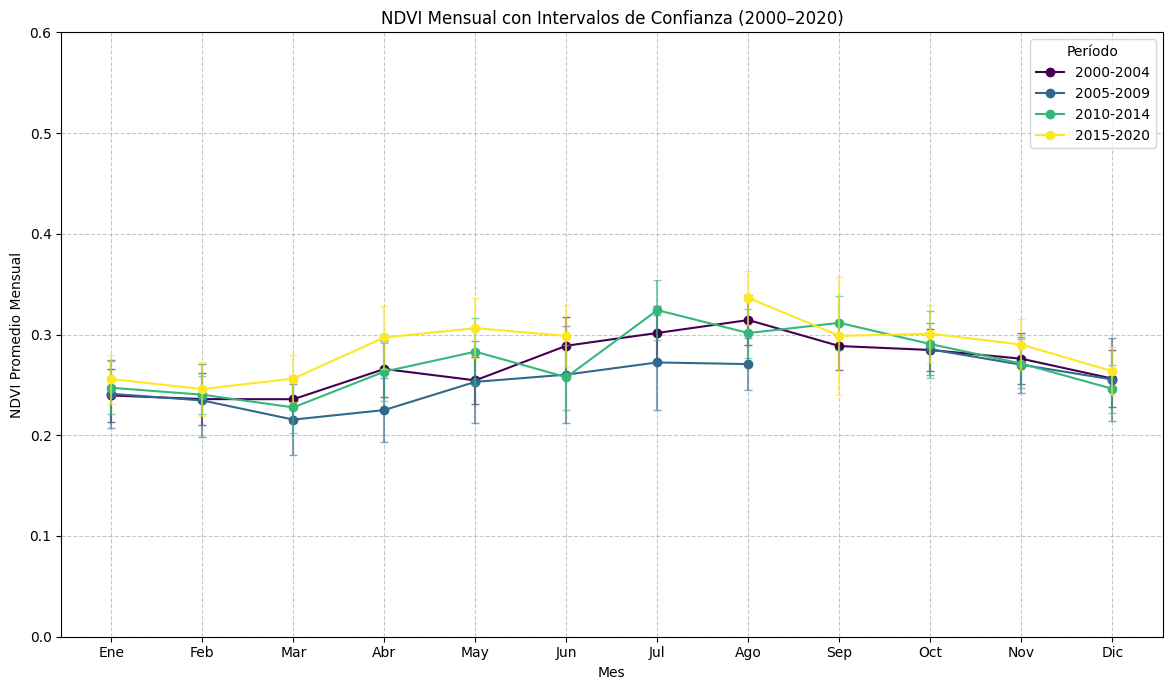

In [60]:
graficar_ndvi(zona_BPQ)


## Zona de BQ abierto

251


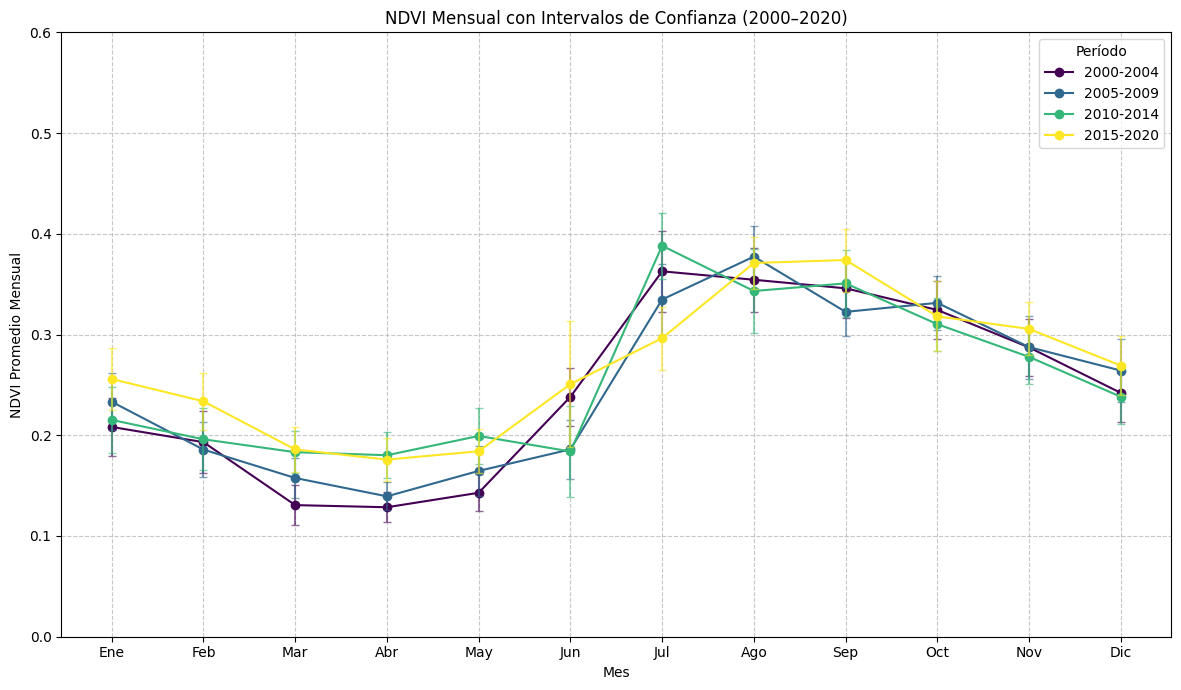

In [61]:
graficar_ndvi(zona_BQ)

## Zona de pastizal

251


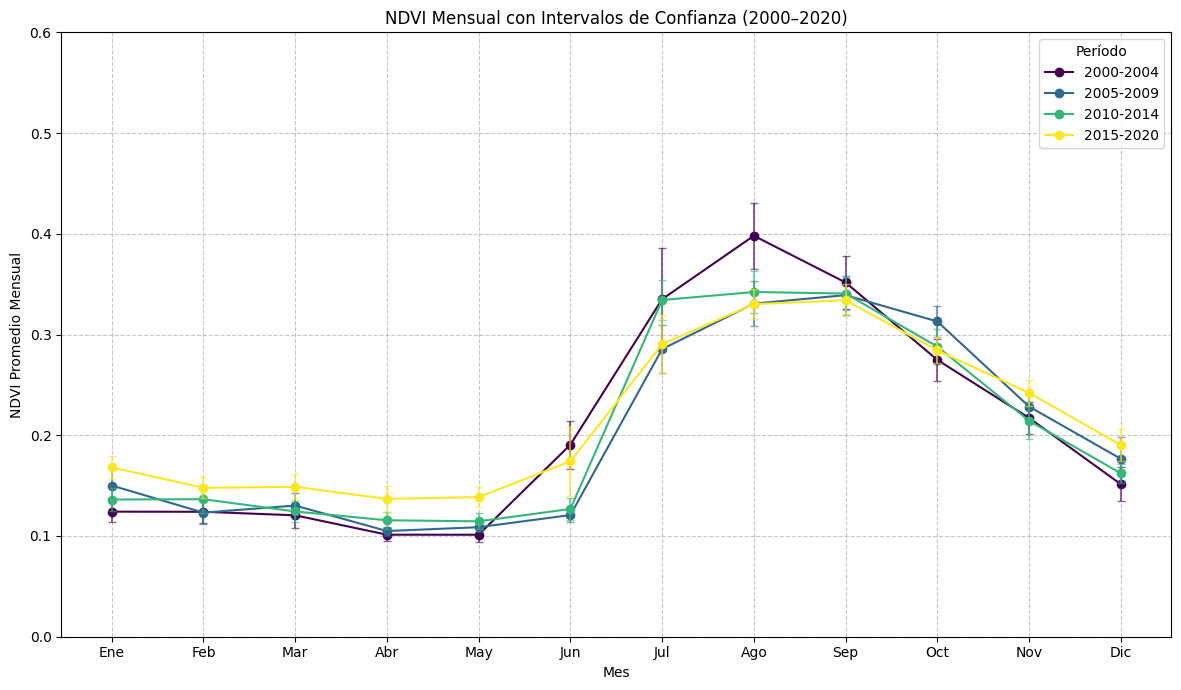

In [62]:
graficar_ndvi(zona_P)

## Zona de BTC

251


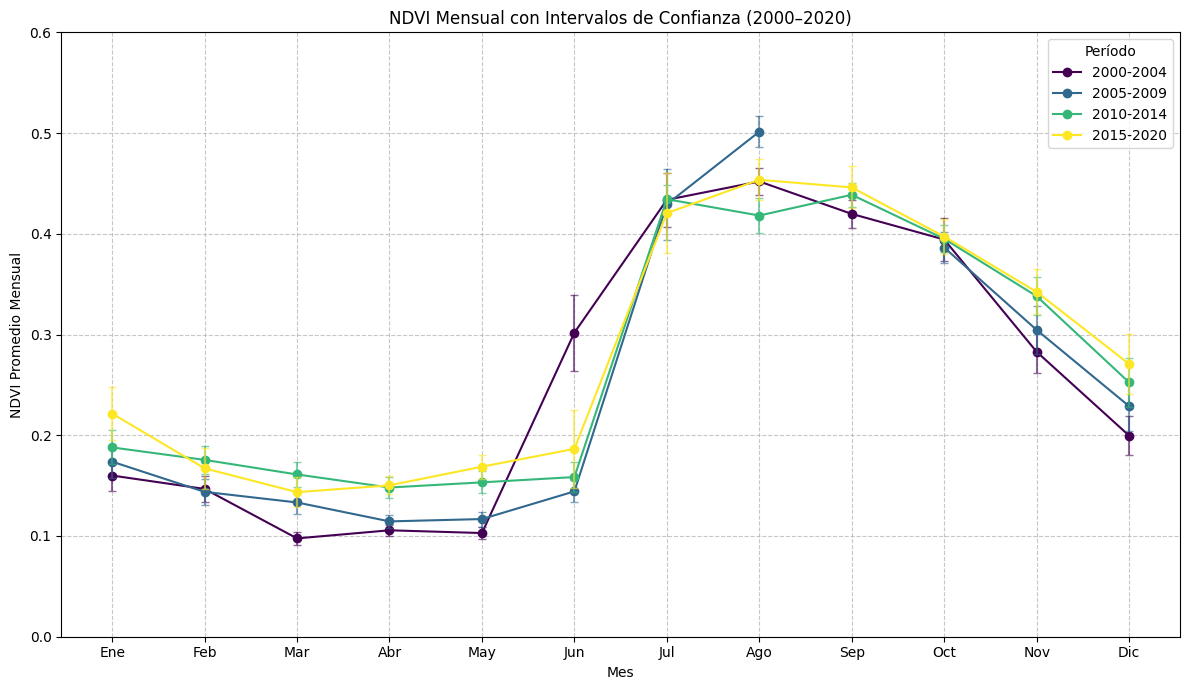

In [63]:
graficar_ndvi(zona_BTC)

### Totalidad de Seierra de Tapalpa

251


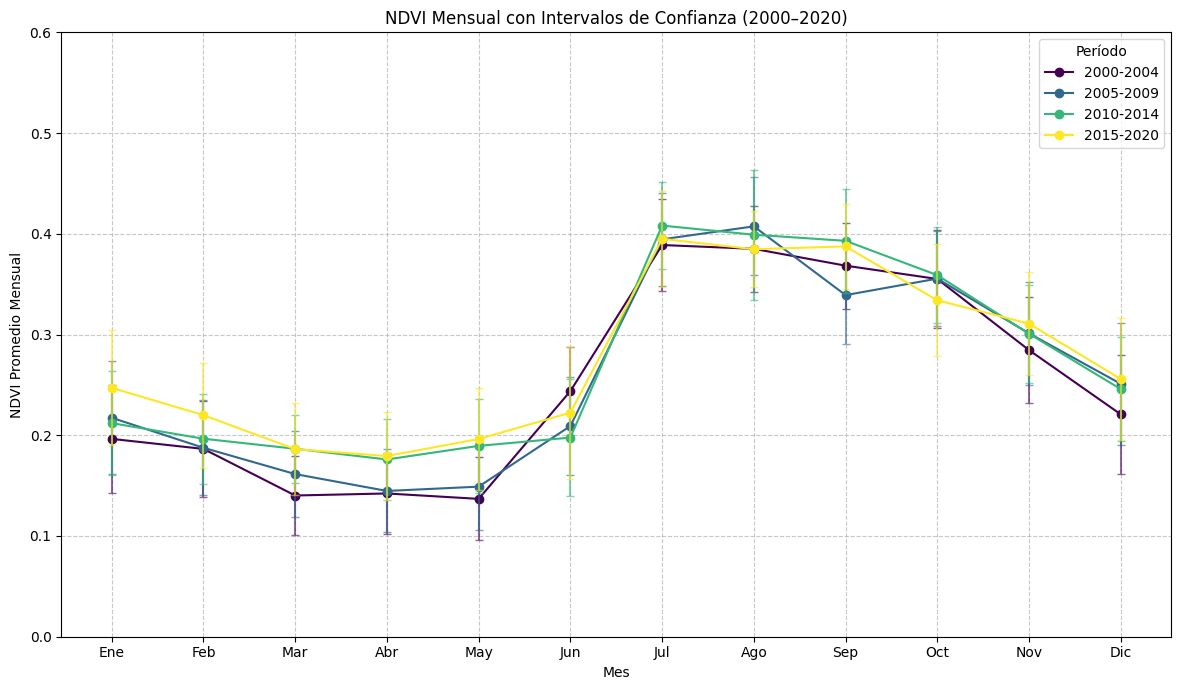

In [64]:
graficar_ndvi(sierratapalpa)